### Compare Forcing Data Sources at PPSA2

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **rasterio**

In [51]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import dates
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

## Open HRRR-AK Data

In [32]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_ppsa2.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time: 8760)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025-10-...
    valid_time    (time) datetime64[ns] 70kB ...
    step          (time) timedelta64[ns] 70kB ...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 70kB ...
    pressure      (time) float64 70kB ...
    orog          (time) float64 70kB ...
    temp_surface  (time) float64 70kB ...
    swe           (time) float64 70kB ...
    snowdepth     (time) float64 70kB ...
    ...            ...
    swrad         (time) float64 70kB ...
    lwrad         (time) float64 70kB ...
    suswrf        (time) float64 70kB ...
    sulwrf        (time) float64 70kB ...
    wind          (time) float64 70kB ...
    wind_dir      (time) float64 70kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       ppsa2
    original_lat:    58.262
    original_lon:    -134.517
    utm_x:           528340.7656649345
    utm_y:           6457981.62778889

### HRRR-AK Precipiation Variables 

In [33]:
# ds['precip_total'] in kg/m2 
# ds['precip_rate'] in kg/m2/s

ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr
ds['precip_accum_total'] = ds['precip_accum_1hr'].cumsum(dim='time') # cumulative precip in mm

# print the fist and last time steps to check the time range of the data
print("First time step:", ds['time'][0].values)
print("Last time step:", ds['time'][-1].values)


First time step: 2024-10-01T05:00:00.000000000
Last time step: 2025-10-01T04:00:00.000000000


In [34]:
# cut the ds from the same time as df 
start_time = '2024-10-01T05:00'
end_time = '2025-06-01T00:00'

# Use .sel() with slice to select the time range
ds = ds.sel(time=slice(start_time, end_time))

## Open PPSA2 Station Observations

In [35]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met_raw = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met_raw['datetime'] = pd.to_datetime(df_met_raw['utc_valid'], utc=True)
df_met_raw = df_met_raw.set_index('datetime')

df_met_raw.columns

Index(['station', 'utc_valid', 'PCIRZZ', 'PCIRZZZ', 'RNIRZZ', 'SDIRZZ',
       'SDIRZZZ', 'TAIRZZ', 'TAIRZZZ', 'UDIRZZ', 'UHIRZZZ', 'UPIRZZ',
       'UPIRZZZ', 'USIRZZ', 'USIRZZZ', 'VBIRZZ', 'VBIRZZZ', 'XRIRZZ',
       'XRIRZZZ'],
      dtype='object')

In [30]:
# create a dataframe, df_met, which contains only the datetime, PCIRZZZ, SDIRZZZ, TAIRZZZ, XRIRZZZ
df_met = df_met_raw[['PCIRZZZ', 'SDIRZZZ', 'TAIRZZZ', 'XRIRZZZ']].copy()

# cut to the same datetime as hrrr-ak
df_met = df_met.loc['2024-10-01T05:00':'2025-06-01T00:00']
df_met

,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ
datetime,,,,
2024-10-01 05:00:00+00:00,278.62,17.08,37.2,92.6
2024-10-01 06:00:00+00:00,278.66,17.28,37.5,93.3
2024-10-01 07:00:00+00:00,278.66,17.08,38.2,93.8
2024-10-01 08:00:00+00:00,278.70,16.48,39.1,92.5
2024-10-01 09:00:00+00:00,278.70,17.28,39.7,91.5
...,...,...,...,...
2025-05-31 20:00:00+00:00,87.60,16.48,39.1,97.0
2025-05-31 21:00:00+00:00,87.60,16.07,40.1,92.2
2025-05-31 22:00:00+00:00,87.60,16.76,40.3,92.1


## Clean up the df_met station data for ppsa a bit

In [41]:
# remove any PCIRZZZ values that are above 150
df_met['precip_accum_total'] = (df_met['PCIRZZZ'].where(df_met['PCIRZZZ'] <= 150)) * 25.4 # convert from inches to mm

# now, calculate the precipitation rate in mm/hr from the cumulative precip, and then convert to mm/s to compare with the model output
# df_met['precip_rate'] = df_met['precip_accum_total'].diff() / 1 # convert from mm/hr to mm/s (since the data is hourly, diff() gives us the change in precip per hour, so we divide by 1 to get mm/hr, then

# compute diff
diff = df_met["precip_accum_total"].diff()

# detect time gaps
time_diff = df_met.index.to_series().diff().dt.total_seconds()

# mask bad intervals
bad = (
    df_met["precip_accum_total"].isna() |
    df_met["precip_accum_total"].shift(1).isna() |
    (time_diff > 3600)
)

df_met["precip_accum_1hr"] = diff.mask(bad)

In [48]:
# get all the variables consistent first 
df_met['RH'] = df_met['XRIRZZZ']
df_met['HS'] = df_met['SDIRZZZ'] * 2.54 # convert from inches to mm, this is the snow depth in mm

# lightly clean HS so that no values are over 250cm 
df_met['HS'] = df_met['HS'].where(df_met['HS'] < 250, np.nan)

df_met['TA'] = (df_met['TAIRZZZ'] - 32) * 5/9 # convert from F to C
df_met.head()


,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,precip_accum_total,precip_accum_1hr,RH,HS,TA
datetime,,,,,,,,,
2024-10-01 05:00:00+00:00,278.62,17.08,37.2,92.6,NaN,NaN,92.6,43.3832,2.888889
2024-10-01 06:00:00+00:00,278.66,17.28,37.5,93.3,NaN,NaN,93.3,43.8912,3.055556
2024-10-01 07:00:00+00:00,278.66,17.08,38.2,93.8,NaN,NaN,93.8,43.3832,3.444444
2024-10-01 08:00:00+00:00,278.70,16.48,39.1,92.5,NaN,NaN,92.5,41.8592,3.944444
2024-10-01 09:00:00+00:00,278.70,17.28,39.7,91.5,NaN,NaN,91.5,43.8912,4.277778


# Compare Precipiation Variables

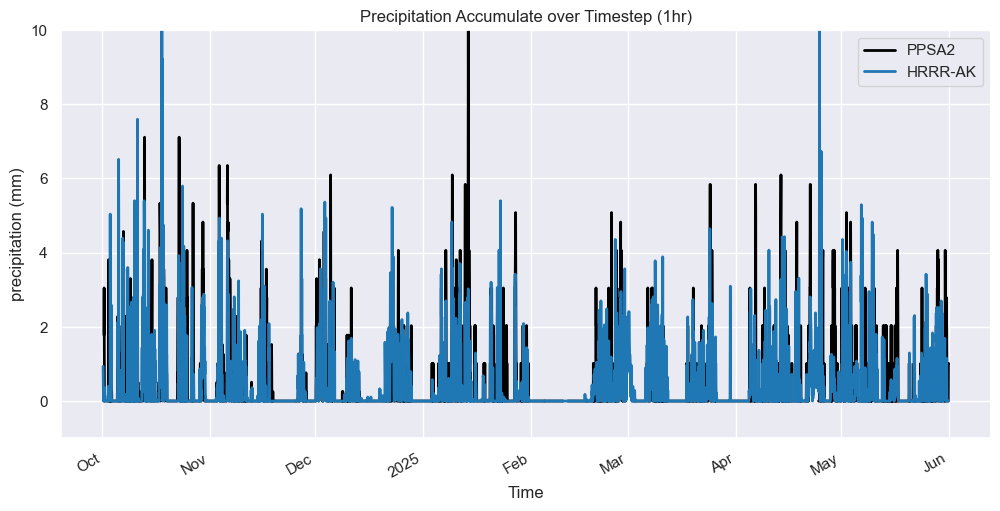

In [45]:
df_met['precip_accum_1hr'].plot(label='PPSA2', color='black', linewidth=2) # obs
ds['precip_accum_1hr'].plot(label='HRRR-AK', color='tab:blue', linewidth=2) # model

plt.title('Precipitation Accumulate over Timestep (1hr)')
plt.xlabel('Time')
plt.ylabel('precipitation (mm)')
plt.legend()

plt.ylim(-1,10)
# zoom into a few days 
# plt.xlim('2023-12-01', '2023-12-10')

plt.show()

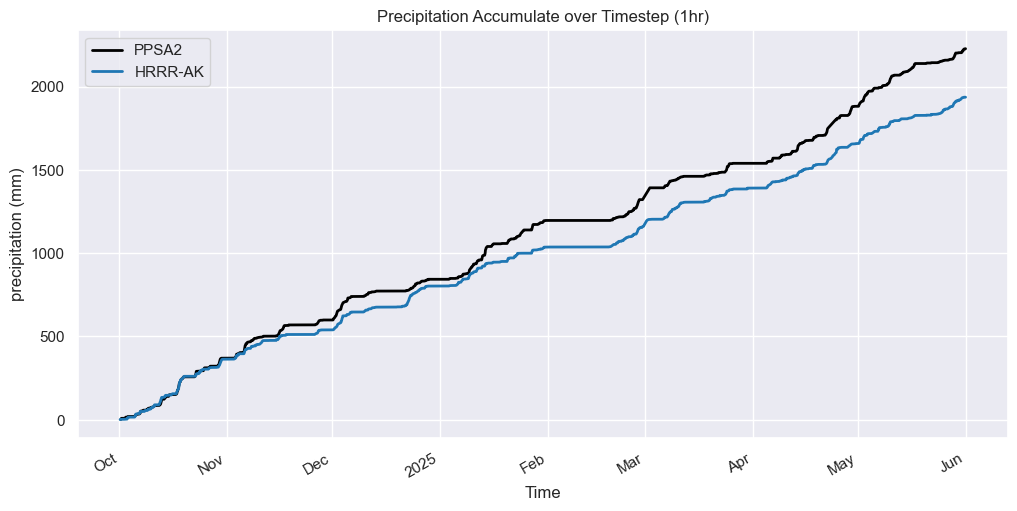

In [44]:
df_met['precip_accum_total'].plot(label='PPSA2', color='black', linewidth=2) # obs
ds['precip_accum_total'].plot(label='HRRR-AK', color='tab:blue', linewidth=2) # model

plt.title('Precipitation Accumulate over Timestep (1hr)')
plt.xlabel('Time')
plt.ylabel('precipitation (mm)')
plt.legend()

# plt.ylim(-1,10)
# zoom into a few days 
# plt.xlim('2023-12-01', '2023-12-10')

plt.show()

## Plot other variables

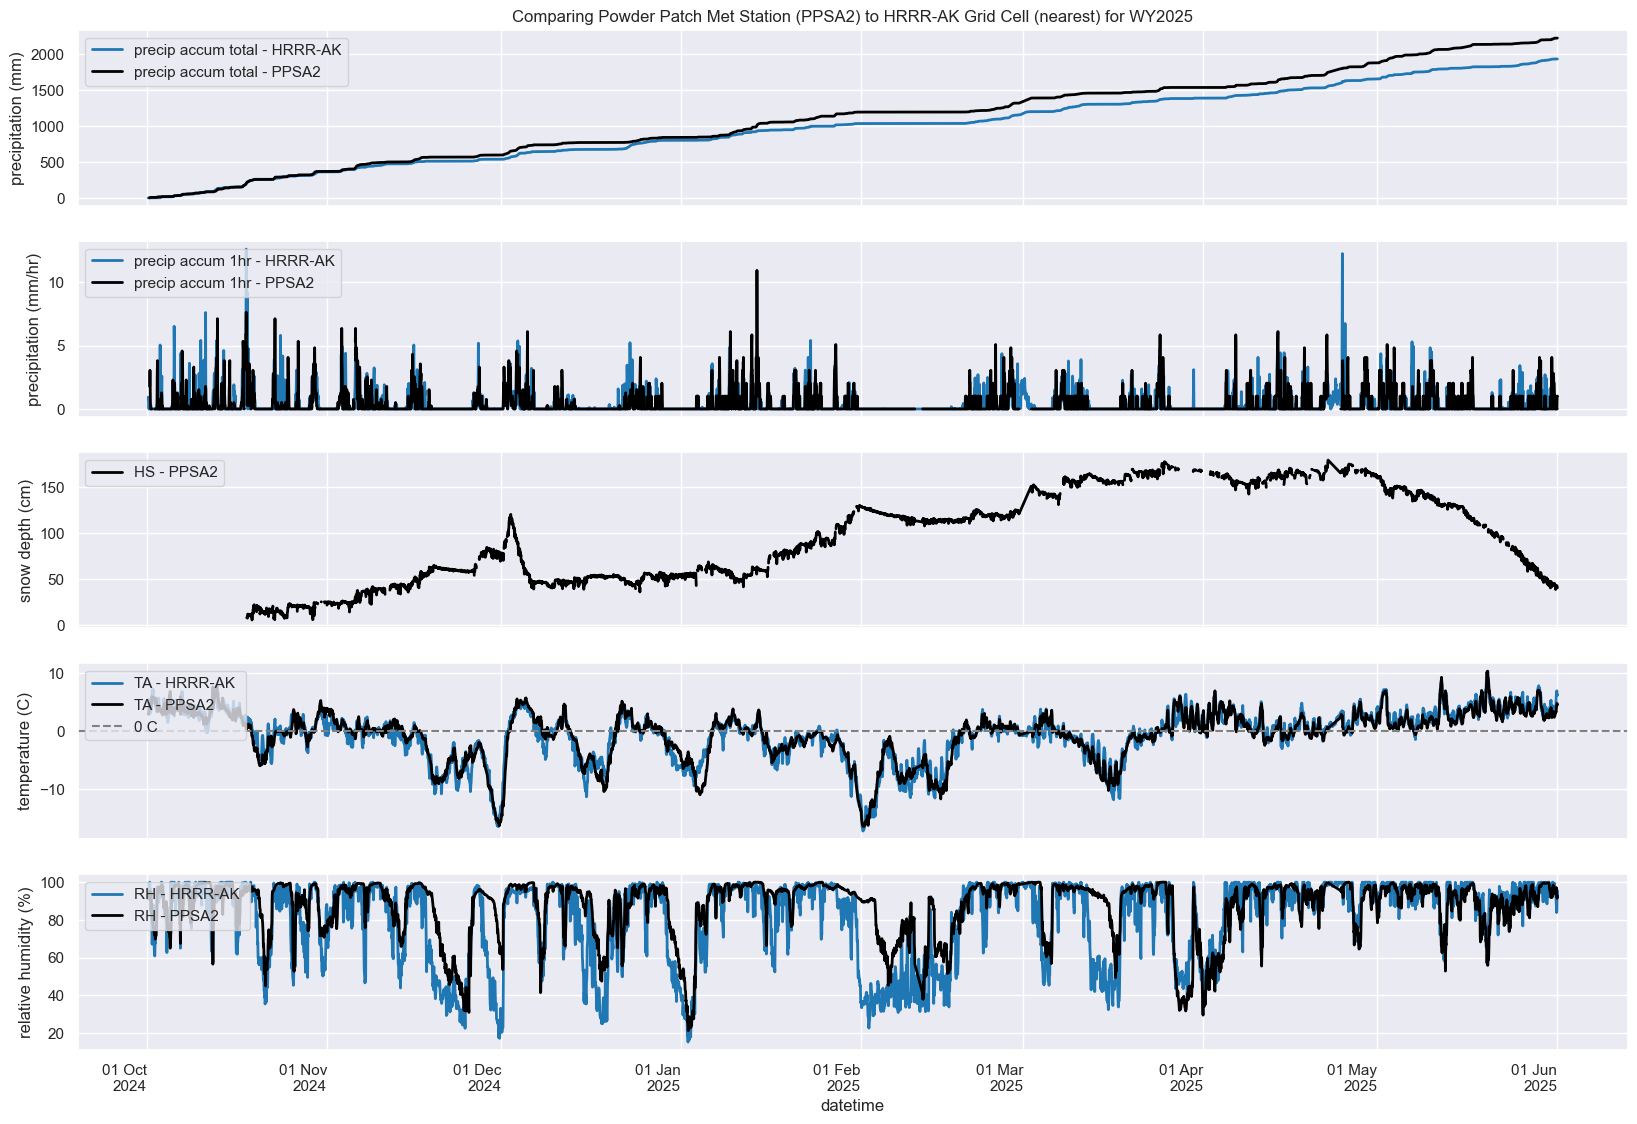

In [63]:
fig, ax = plt.subplots(5, 1, figsize=(20, 15), sharex=True)

# and add in the hrrr-ak variables which match 
ds['precip_accum_total'].plot(ax=ax[0], linestyle='-', label='precip accum total - HRRR-AK', linewidth=2, color='tab:blue')  # mm
ds['precip_accum_1hr'].plot(ax=ax[1], linestyle='-', label='precip accum 1hr - HRRR-AK', linewidth=2, color='tab:blue')  # mm/hr

(ds['temp'] - 273.15).plot(ax=ax[3], linestyle='-', label='TA - HRRR-AK ', linewidth=2, color='tab:blue')  # convert K to C
ds['rh'].plot(ax=ax[4], linestyle='-', label='RH - HRRR-AK ', linewidth=2, color='tab:blue')  # %


# df_met data 
df_met['precip_accum_total'].plot(ax=ax[0], linewidth=2, label='precip accum total - PPSA2', color='black') # mm
df_met['precip_accum_1hr'].plot(ax=ax[1], linewidth=2, label='precip accum 1hr - PPSA2', color='black') # mm/hr

df_met['HS'].plot(ax=ax[2], linewidth=2, label='HS - PPSA2', color='black') # in inches 
df_met['TA'].plot(ax=ax[3], linewidth=2, label='TA - PPSA2', color='black') # now in C
df_met['RH'].plot(ax=ax[4], linewidth=2, label='RH - PPSA2', color='black')


ax[3].axhline(y=0, color='grey', linestyle='--', label='0 C')

# Labels 
ax[0].set_title('Comparing Powder Patch Met Station (PPSA2) to HRRR-AK Grid Cell (nearest) for WY2025')
ax[1].set_title('')
ax[2].set_title('')
ax[3].set_title('')
ax[4].set_title('')

ax[0].set_ylabel('precipitation (mm)')
ax[1].set_ylabel('precipitation (mm/hr)')
ax[2].set_ylabel('snow depth (cm)')
ax[3].set_ylabel('temperature (C)')
ax[4].set_ylabel('relative humidity (%)')
        
# Set common x-label for all subplots
ax[-1].set_xlabel('datetime')
ax[-1].xaxis.set_major_formatter(dates.DateFormatter('%d %b\n%Y')) #'%d %b\n%Y'
plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=360)

# select daterange 
# start_date = '2024-10-01'
# end_date = '2025-06-01'
# # Filter the x-axis to show only the specified date range
# for a in ax:
#     a.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# show a legend on all subplots
loc = 'upper left'
ax[0].legend(loc=loc)
ax[1].legend(loc=loc)
ax[2].legend(loc=loc)
ax[3].legend(loc=loc)
ax[4].legend(loc=loc)

plt.show()

In [57]:
# Clean it up for snow depth: Apply masks for specific months and thresholds
# October: if HS > 50, set to NaN
mask_oct = (df_met.index.month == 10) & (df_met['HS'] > 25)
df_met.loc[mask_oct, 'HS'] = np.nan

# October and November and December: if HS < 5, set to NaN
mask_oct_nov = (df_met.index.month.isin([10, 11, 12])) & (df_met['HS'] < 5)
df_met.loc[mask_oct_nov, 'HS'] = np.nan

# February, March, April, May: if HS > 200, set to NaN
mask_feb_may = (df_met.index.month.isin([2, 3, 4, 5])) & (df_met['HS'] > 200)
df_met.loc[mask_feb_may, 'HS'] = np.nan

# Optional: Print summary of changes
print(f"October values set to NaN: {mask_oct.sum()}")
print(f"Feb-May values set to NaN: {mask_feb_may.sum()}")
print(f"Total NaN values in 'HS': {df_met['HS'].isna().sum()}")

October values set to NaN: 281
Feb-May values set to NaN: 0
Total NaN values in 'HS': 979


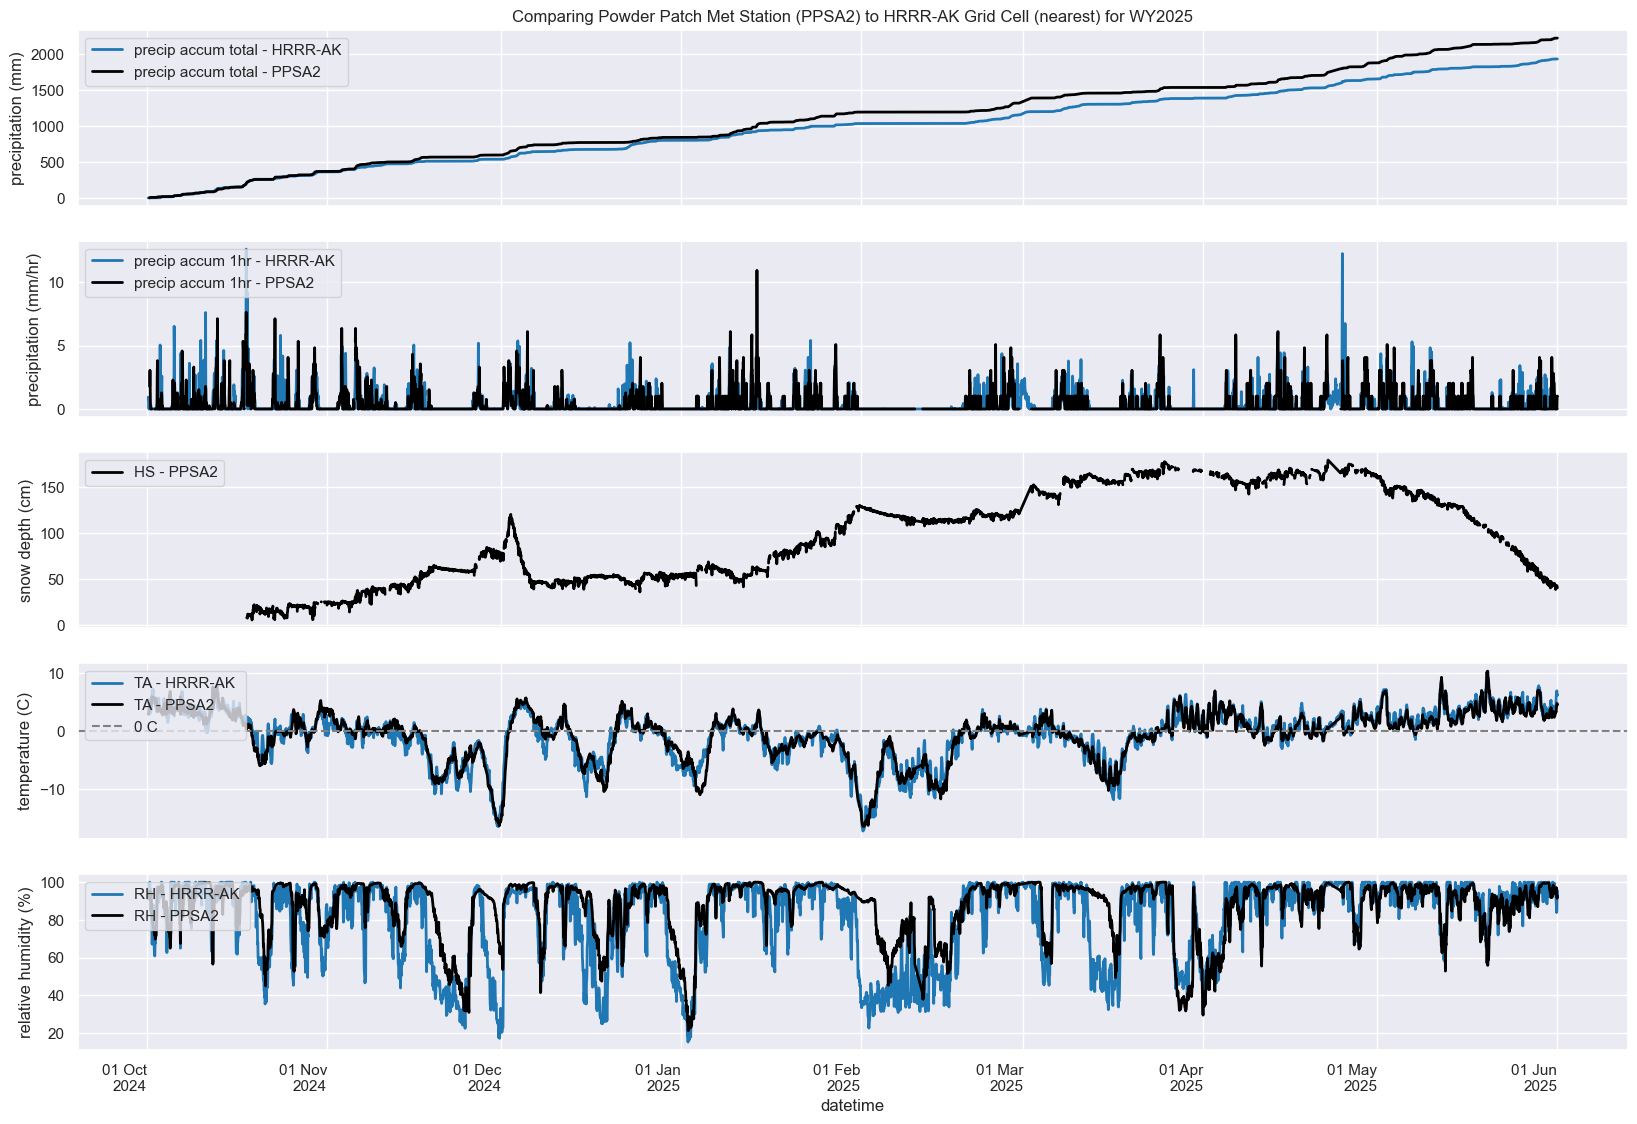

In [65]:
fig, ax = plt.subplots(5, 1, figsize=(20, 15), sharex=True)

# and add in the hrrr-ak variables which match 
ds['precip_accum_total'].plot(ax=ax[0], linestyle='-', label='precip accum total - HRRR-AK', linewidth=2, color='tab:blue')  # mm
ds['precip_accum_1hr'].plot(ax=ax[1], linestyle='-', label='precip accum 1hr - HRRR-AK', linewidth=2, color='tab:blue')  # mm/hr

(ds['temp'] - 273.15).plot(ax=ax[3], linestyle='-', label='TA - HRRR-AK ', linewidth=2, color='tab:blue')  # convert K to C
ds['rh'].plot(ax=ax[4], linestyle='-', label='RH - HRRR-AK ', linewidth=2, color='tab:blue')  # %


# df_met data 
df_met['precip_accum_total'].plot(ax=ax[0], linewidth=2, label='precip accum total - PPSA2', color='black') # mm
df_met['precip_accum_1hr'].plot(ax=ax[1], linewidth=2, label='precip accum 1hr - PPSA2', color='black') # mm/hr

df_met['HS'].plot(ax=ax[2], linewidth=2, label='HS - PPSA2', color='black') # in inches 
df_met['TA'].plot(ax=ax[3], linewidth=2, label='TA - PPSA2', color='black') # now in C
df_met['RH'].plot(ax=ax[4], linewidth=2, label='RH - PPSA2', color='black')


ax[3].axhline(y=0, color='grey', linestyle='--', label='0 C')

# Labels 
ax[0].set_title('Comparing Powder Patch Met Station (PPSA2) to HRRR-AK Grid Cell (nearest) for WY2025')
ax[1].set_title('')
ax[2].set_title('')
ax[3].set_title('')
ax[4].set_title('')

ax[0].set_ylabel('precipitation (mm)')
ax[1].set_ylabel('precipitation (mm/hr)')
ax[2].set_ylabel('snow depth (cm)')
ax[3].set_ylabel('temperature (C)')
ax[4].set_ylabel('relative humidity (%)')
        
# Set common x-label for all subplots
ax[-1].set_xlabel('datetime')
ax[-1].xaxis.set_major_formatter(dates.DateFormatter('%d %b\n%Y')) #'%d %b\n%Y'
plt.setp(ax[-1].xaxis.get_majorticklabels(), rotation=360)

# select daterange 
# start_date = '2024-10-01'
# end_date = '2025-06-01'
# # Filter the x-axis to show only the specified date range
# for a in ax:
#     a.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# show a legend on all subplots
loc = 'upper left'
ax[0].legend(loc=loc)
ax[1].legend(loc=loc)
ax[2].legend(loc=loc)
ax[3].legend(loc=loc)
ax[4].legend(loc=loc)

plt.show()